In [270]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
from pandas import read_csv
import numpy as np

from pandas import Series
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import scipy as sp
import matplotlib.pylab as plt
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
from pandas import DataFrame

In [260]:
data = pd.read_excel('IPCCaliVaryearlycorrido.xlsx')
#df.index.freq = 'MS'
cali_ts=data["Cali"]
data.head()
data=data[['Fecha','Cali']]
type(data) # tipo
print(data)
print('\n Data Types:')
print(data.dtypes)

len(data)

,Fecha,Cali
0,1979-01-31,2.3
1,1979-02-28,3.6
2,1979-03-31,8.1
3,1979-04-30,9.8
4,1979-05-31,11.4


pandas.core.frame.DataFrame

         Fecha   Cali
0   1979-01-31   2.30
1   1979-02-28   3.60
2   1979-03-31   8.10
3   1979-04-30   9.80
4   1979-05-31  11.40
..         ...    ...
511 2021-08-31   4.37
512 2021-09-30   4.65
513 2021-10-31   4.65
514 2021-11-30   5.06
515 2021-12-31   5.83

[516 rows x 2 columns]

 Data Types:
Fecha    datetime64[ns]
Cali            float64
dtype: object


516

In [261]:
from __future__ import print_function
import os
import sys
import pandas as pd
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns
import datetime
import scipy as sp

<Figure size 396x396 with 0 Axes>

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Box plot del IPC del Valle')

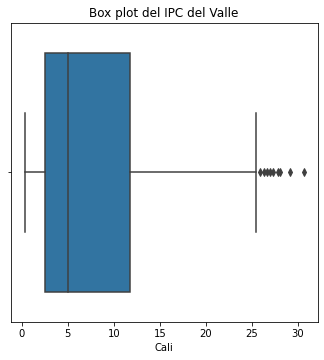

In [263]:
df=data
plt.figure(figsize=(5.5, 5.5))
g = sns.boxplot(df['Cali']) 
g.set_title('Box plot del IPC del Valle')

In [265]:
indice=df['Fecha']
CALIdf =pd.DataFrame(df['Cali'].values,index=indice)
CALIdf.head(10)
type(CALIdf)

,0
Fecha,
1979-01-31,2.3
1979-02-28,3.6
1979-03-31,8.1
1979-04-30,9.8
1979-05-31,11.4
1979-06-30,12.3
1979-07-31,14.3
1979-08-31,16.6
1979-09-30,19.8


pandas.core.frame.DataFrame

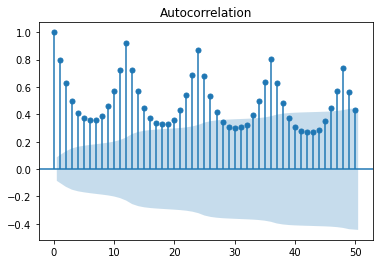

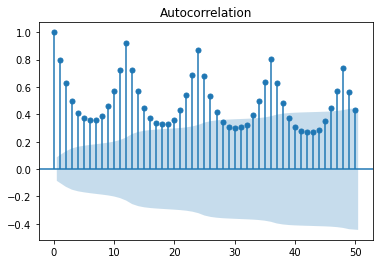

In [266]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
plot_acf(CALIdf,lags=50)
plt.show()

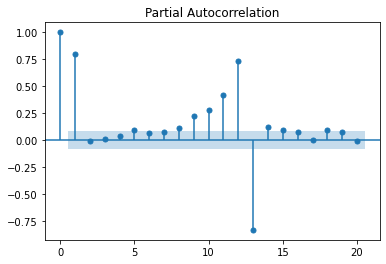

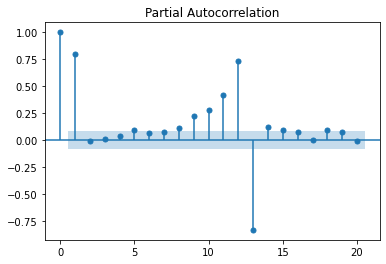

In [267]:
plot_pacf(CALIdf,lags=20,method='ldbiased')
plt.show()

1
0.001937984496124031
516.0


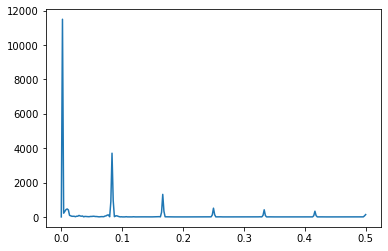

In [268]:
f, Pxx_den=sp.signal.periodogram(df['Cali'])
plt.plot(f, Pxx_den)
#plt.axvline(x=1/50,color='red')
max_index_value = np.argmax(Pxx_den, axis=0)
print(max_index_value)
frecuencia_max=f[max_index_value]
print(frecuencia_max)
print(1/frecuencia_max)

In [269]:
indice=df['Fecha']
CALIdf_alt =pd.DataFrame(df[['Cali','Fecha']])
CALI_alt_df = CALIdf_alt.set_index('Fecha')
CALI_alt_df

,Cali
Fecha,
1979-01-31,2.30
1979-02-28,3.60
1979-03-31,8.10
1979-04-30,9.80
1979-05-31,11.40
...,...
2021-08-31,4.37
2021-09-30,4.65
2021-10-31,4.65


In [272]:
df1 = DataFrame()
for i in range(5,0,-1):
    df1[['t-'+str(i)]] = CALIdf.shift(i)
print(df1)
df1['t'] = CALIdf.values
df1_CALI = df1[5:]
print(df1_CALI.head(6))
df1_CALI.shape

             t-5   t-4   t-3   t-2   t-1
Fecha                                   
1979-01-31   NaN   NaN   NaN   NaN   NaN
1979-02-28   NaN   NaN   NaN   NaN  2.30
1979-03-31   NaN   NaN   NaN  2.30  3.60
1979-04-30   NaN   NaN  2.30  3.60  8.10
1979-05-31   NaN  2.30  3.60  8.10  9.80
...          ...   ...   ...   ...   ...
2021-08-31  1.56  2.14  4.97  3.68  3.94
2021-09-30  2.14  4.97  3.68  3.94  4.37
2021-10-31  4.97  3.68  3.94  4.37  4.65
2021-11-30  3.68  3.94  4.37  4.65  4.65
2021-12-31  3.94  4.37  4.65  4.65  5.06

[516 rows x 5 columns]
             t-5   t-4   t-3   t-2   t-1     t
Fecha                                         
1979-06-30   2.3   3.6   8.1   9.8  11.4  12.3
1979-07-31   3.6   8.1   9.8  11.4  12.3  14.3
1979-08-31   8.1   9.8  11.4  12.3  14.3  16.6
1979-09-30   9.8  11.4  12.3  14.3  16.6  19.8
1979-10-31  11.4  12.3  14.3  16.6  19.8  21.2
1979-11-30  12.3  14.3  16.6  19.8  21.2  23.4


(511, 6)

In [273]:
CALIsplit = df1_CALI.values

X1= CALIsplit[:, 0:-1]  
y1= CALIsplit[:,-1] 

In [274]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [275]:
X_train_full, X_test, y_train_full, y_test=train_test_split(X1,
                                                            y1,
                                                            test_size=0.15, 
                                                            train_size=0.85,
                                                            shuffle=False)

In [276]:
X_train, X_val, y_train, y_val=train_test_split(X_train_full,
                                                y_train_full,
                                                test_size=1-0.8823529412, 
                                                train_size=0.8823529412,
                                                shuffle=False)

In [277]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model

In [278]:
model=keras.models.Sequential([
    keras.layers.Dense(32,activation="relu",input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam()
model.summary()

Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_24 (Dense)             (None, 32)                192       
_________________________________________________________________
dense_25 (Dense)             (None, 1)                 33        
Total params: 225
Trainable params: 225
Non-trainable params: 0
_________________________________________________________________


In [279]:
model.compile(loss="mean_squared_error",optimizer="adam")
history=model.fit(X_train,y_train,epochs=50,validation_data=(X_val,y_val))

Epoch 1/50
12/12 [==============================] - 0s 8ms/step - loss: 482.8309 - val_loss: 10.9552
Epoch 2/50
12/12 [==============================] - 0s 2ms/step - loss: 341.6033 - val_loss: 7.1457
Epoch 3/50
12/12 [==============================] - 0s 2ms/step - loss: 232.8884 - val_loss: 4.4457
Epoch 4/50
12/12 [==============================] - 0s 2ms/step - loss: 157.8335 - val_loss: 2.6759
Epoch 5/50
12/12 [==============================] - 0s 2ms/step - loss: 108.7651 - val_loss: 1.7036
Epoch 6/50
12/12 [==============================] - 0s 2ms/step - loss: 82.1656 - val_loss: 1.2099
Epoch 7/50
12/12 [==============================] - 0s 2ms/step - loss: 69.8990 - val_loss: 0.9878
Epoch 8/50
12/12 [==============================] - 0s 2ms/step - loss: 62.4037 - val_loss: 0.9153
Epoch 9/50
12/12 [==============================] - 0s 2ms/step - loss: 58.9211 - val_loss: 0.8786
Epoch 10/50
12/12 [==============================] - 0s 2ms/step - loss: 56.2755 - val_loss: 0.8552
Epo

<AxesSubplot:>

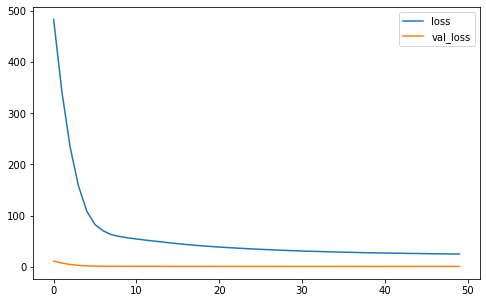

In [280]:
pd.DataFrame(history.history).plot(figsize=(8,5))

In [281]:
np.random.seed(1)
mse_test_RN=model.evaluate(X_test,y_test)
print(mse_test_RN)

3/3 [==============================] - 0s 1ms/step - loss: 1.2838
1.2838443517684937


In [ ]:
ypred=model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.plot(range(y_test.size), y_test, linestyle='-', marker='*', color='r')
plt.plot(range(ypred.size), ypred, linestyle='-', marker='.', color='b') 
plt.legend(['Actual','Prediccion'], loc=2)
plt.title('Actual vs Prediccion')
plt.ylabel('Valor del oro')
plt.xlabel('Indice')